# Problem Set AJR. Governance & Prosperity III

## 0. Background

These problem set assignments are a required part of the course.

Collaborating on the problem sets is more than okay—it is encouraged! Seek help from a classmate or an instructor or a roommate or a passerby when you get stuck! (Explaining things is beneficial, too—the best way to solidify your knowledge of a subject is to explain it.) 

But the work should be your own.

No cutting-&-pasting from others' problem sets, please! We want you to learn this stuff, and your fingers typing every keystroke is an important way of building muscle memory here.

In this problem set, you will investigate if we can tell whether quality of governance is an important cause or consequence of prosperity. This problem set is, like the previous one, adapted from one at the excellent Quantecon, which is run by John Stachurski and Thomas Sargent. The unit is: _Linear Regression in Python_ <https://python.quantecon.org/ols.html>

This is an odd problem set. I lead you through the analysis, but there is relatively little programming for you to do.

Let us get started!

&nbsp;

## 1. Preliminaries: Computing Environment

As before, we set up the computing environment. We once again start by making sure our charts do not appear in extra windows:

In [1]:
# ajr.1.1. set up the computing environment: ensure that graphs
# appear inline in the notebook & not in extra windows:

# REMOVE THE FOLLOWING LINE BEFORE DEPLOYMENT
%matplotlib inline 

# remember how to do this? take a look at the past problem sets if you have forgotten...
# ...

We load our standard libraries:

In [2]:
# ajr.1.2. set up the computing environment: import standard libraries

import numpy as np  # REMOVE BEFORE DEPLOYMENT
import pandas as pd  # REMOVE BEFORE DEPLOYMENT
import matplotlib as mpl  # REMOVE BEFORE DEPLOYMENT
import matplotlib.pyplot as plt  # REMOVE BEFORE DEPLOYMENT

# remember how to do this? take a look at the past problem sets if you have forgotten...
# ...

And, as we did last time, we load an additional library: the "linear [statistical] models" library. If we have a cloud of points that have been generated by a relationship line plus a bunch of other factors that disturb the relationship, the linearmodels library will draw what line the computer thinks is in some sense the most likely line to have produced the data cloud:

In [3]:
# ajr.1.3. set up the computing environment: additional library: linear models:

!pip install linearmodels
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
import linearmodels
from linearmodels.iv import IV2SLS

## 2. Assertions...

### A. Governance & Prosperity

How much of the wide divergence in income and prosperity across countries in the world today reflects good and bad domestic political luck? 

**Daron Acemoglu, Simon Johnson, & James Robinson**, writing in 2000 in their _The Colonial Origins of Comparative Development: An Empirical Investigation_ <https://github.com/braddelong/public-files/blob/master/readings/article-acemoglu-colonial-origins.pdf>, conclude: a lot. 

In their view, whether a country has good governance—that encourages economic growth, encourages investment through protecting property rights, and is relatively uncorrupt—hinges on the luck of its history. Did it develop institutions that were good for growth, both as a result of the push and pull of politically powerful actors and because of far-sighted decisions by statesmen and stateswomen? Or did it not not?

&nbsp;

### B. The AJR Argument

To understand the argument, let's download the data of **Daron Acemoglu, Simon Johnson, & James Robinson** (2000): _The Colonial Origins of Comparative Development: An Empirical Investigation_ <https://github.com/braddelong/public-files/blob/master/readings/article-acemoglu-colonial-origins.pdf>and take a look at the basic scatter of properity and "governance". The computer plots the quality of governance as estimated by Political Risk Services on the horizontal axis, and the logarithm of real income per capita in the country in 1995 on the vertical axis:

In [4]:
# 8.2.B.1. download the ajr data & look at the basic scatter:
#
# 'governancequality' is as perceived over 1985-1995
# by the PRS Group <https://www.prsgroup.com>
#
# 'logincome' is year-1995 real income per capita
#
# start by reading in the AJR data from the internet:

ajr_df = pd.read_csv('https://delong.typepad.com/files/ajr-2020.csv')

ajr_df.head()

HTTPError: HTTP Error 500: Internal Server Error

In [ ]:
# drop missing observations:

ajr_df = ajr_df.dropna(subset=['logincome', 'governancequality'])

# restrict our analysis to the AJR "base" sample:

ajr_df = ajr_df[ajr_df['basesample'] == 1]

# tell python to expect figures to come 
# by initializing the python objects to hold the figures...

fig, ax = plt.subplots(figsize=(8,8)) 

# create the figure with average expropriation risk on the horizontal and
# 1995 per capita real income on the vertical axis

ax.scatter(ajr_df['governancequality'], ajr_df['logincome'], marker='.')

# now loop through the data[points in the figure, annotating each
# data point with a three letter code ('Threeletterabbrevation') identifying the 
# country refered to:

for i, txt in enumerate(ajr_df['shortid']):
    ax.annotate(txt, (ajr_df['governancequality'].iloc[i], ajr_df['logincome'].iloc[i]))
    

# draw a straight least-squares fit line through the data

ax.plot(np.unique(ajr_df['governancequality']),
    np.poly1d(np.polyfit(ajr_df['governancequality'], ajr_df['logincome'], 1))(np.unique(ajr_df['governancequality'])),
    color='black')

# set the figure labels, and show the figure:


ax.set_xlabel('Perceived Quality of Governance 1985-95', size=16)
ax.set_ylabel('Log Income per Capita, 1995', size=16)
ax.set_title('Basic AJR Scatter: Governance Quality & Prosperity', size=24)
plt.show()

## 3. Statistics...

Note the "least-squares fit line": the computer has calculated and drawn a line according to an equation:

>$ logincome =  \hat{\beta}_{const} + \hat{\beta}_{governancequality}(governancequality) $

What is this "least-squares fit line?" It draws the line for which, when you take the vertical distances from each of the data points to the line, square the distances, and then add them up, that sum is least. In order to draw the line, the computer has to choose two parameters. The first is $ \hat{\beta}_{const} $, a "constant" term: changing it shifts the line up and down, and when it is equal to zero the line must go through the (0,0) point on the graph. The second is $ \hat{\beta}_{governancequality} $, the amount by which a one-unit increase in the variable on the x-axis raises the value of the variable on the y-axis: changing it tilts the line.

Drawing this least-squares fit line is a good thing to do if the data-generating process is composed of (a) a linear straight-line relationship between the x-axis and the y-axis variables, plus (b) an extra ("disturbance") term raising or lowering the y-axis value by a random amount that has a _normal distribution_. Such a normal ditribution means "thin tails": that is, the chance that an observation will be very far from the underlying relationship between the x-axis and y-axis variables is very small, and that chance decreases very very rapidly indeed as you get further away.

Drawing this kind of least-squares best-fit line is called, in statistics, a "regression analysis". If we ask, the computer can tell us a number of things about the statistical characteristics of the line it has just drawn:

In [ ]:
# 8.3.1. since we do not want the relationship between x and y
# to be forced to go through the point (0,0) on the graph,
# we add a variable that is a constant—always equal to one—
# to our dataframe
#
# thus as the computer hunts for the linear best-fit liine we
# allow it both to change the slope of the fitted line and 
# to move it up or down to find the least-squares best fit:

ajr_df['constant'] = 1

print('REGRESSION OF PROSPERITY ON GOVERNANCE QUALITY')

print(sm.OLS(endog=ajr_df['logincome'], 
                exog=ajr_df[['constant', 'governancequality']], 
                missing='drop').fit().summary())

Here:

* "sm" is the "statsmodels" package applications programming interface that we loaded earlier;
* "OLS" means that we are carrying out a least-squares fit in the "ordinary" O (as opposed to, say, a "two stage" 2S) analysis;
* "endog = ajr_df['logincome']" says that the thing we are trying to predict, analyze, and understand is the "logincome" variable in the "ajr_df" dataframe;
* "exog = ajr_df['constant', 'governancequality']" says that we are assuming that logincome is determined by the "governancequality" quality-of-governance variable and the constant term (so that logincome does not have to be zero when avgexpr is zero) in the "ajr_df" dataframe;
* "missing = drop" means that we drop from the analysis any observations—dataframe rows—in which some values of the data are missing;
* "fit" means that we want to look at how well the least-squares line does at "fitting" the data;
* "summary" means that we only want to look at the summary table;
* and "print" means that we want the analysis printed out to the screen so that we can look at it.

For our purposes, there are three most important numbers to look at in this table. 

The first, the first is the 0.540 labeled "R-squared" in the top-right. 

This tells us the proportion of the variation in the variable we are trying to understand—logincome, the log of real income per capita in 1995—that we could forecast if we knew the least-squares line and knew that country's values of our predictor variables—the constant, and the quality of governance avgexpr. The 0.522 tells us that, if quality of governance as we have estimated it is the only systematic determinant of log income per capita, that 52.2% of the variation in log income per capita is accounted for by the variation in quality of governance, and the rest is random variation.

The second number is the 0.644 on the right, just above the third line of equals signs "...======". 

It tells us that, if this regression analysis is correctly specified (i.e., quality of governance as we have estimated it is the only systematic determinant of log income per capita), and if the random disturbances to log income per capita have nothing to do with each other (are "independent"), and if these disturbances have a normal distribution ("thin tales"), and if the data were generated starting from values of the constant and of governance quality governancequality by the equation:

>$ logincome =  \beta_{const} + \beta_{governancequality}(governancequality) + \epsilon $

where the $ \epsilon $ is the independent normally-distributed random disturbance,

then there is only a 2.5% chance that the "true" $ \beta_{governancequality} $ that generated the data is greater than 0.644.

(Or, rather, only a 2.5% chance that 0.644 is greater than the "true" $ \beta $ that generated the data. The true $ \beta $ is what it is, and is not affected by what the data turned out to be. The 0.644 is a random variable that could have been high and could have been low. There was only a 2.5% chance that it would be higher than the true $ \beta_{governancequality} $. But now that it has been calculated and realized, it is either higher than the true $ \beta $ or it is not—but since you do not know the true $ \beta_{governancequality} $, you do not know which is the case.)

Now this 0.644 has a somewhat strange ontological status. It is a number that is "true" if a number of other things are true none of which are true: quality of governance is not the only systematic determinant, the random disturbances are not independent, they do not have a normal distribution, and the data were not generated by the equation. Thus assessing the relationship between the number and our reality requires some thought.

The third number is the 0.400. It is the cousin of the 0.644. If there really were only a 2.5% chance that when you calculated the number that turned out to be 0.644 it would be higher than the true $ \beta $, there would similarly be only a 2.5% chance that when you calculated the number that turned out to be 0.400 it would be lowere than the true $ \beta $.

We call the range [0.400, 0.644] the *confidence interval*. And we say that it is statistically unlikely that this randomly generated confidence interval that is a function of how pure chance generated the disturbance causes of real income per capita lies entirely outside of the true $ \beta $. Whenever zero is not included in the confidence interval, people tend to say that that fact is "statistically significant". But it is better to avoid saying that, as it tends to lead to very fuzzy and misleading thinking.

&nbsp;

## 4. Quantitative Relationships...

Now let's, for a moment, put aside all the statistical uncertainty issues. Let us suppose that the values of the equation:

>$ logincome =  \hat{\beta}_{constant} + \hat{\beta}_{governancequality}(governancequality) $

that our statistical analysis has estimated are the true values, and they are as given by the first numbers in the lines that start with "constant" and "governancequality":

>$ \hat{\beta}_{constant} = 4.6604 $    
$ \hat{\beta}_{governancequality} = 0.5221 $

Thus if governance quality were zero, we would expect the log of income per capita to be 4.66. And we would expect every one-unit increase in governance quality to carry with it an 0.522 increase in the log of income per capita.

What does such an equation mean?

First, what does a log of 4.6604 mean? Let's calculate it in the cell below:

In [ ]:
# 8.4.1. calculate the annual per-capita income level for which log income per capita is 4.6604

y_4point6 = np.exp(4.6604) # REMOVE THIS BEFORE DEPLOYMENT

# y_4point6 UNCOMMENT THIS

print("$",y_4point6, "/per year   is the annual income per capita level for which logincome is 4.6604" )

But we do not get governance quality scores less than 4. What is the same calculation for a governance quality score of 4, given our two parameters 4.66 and 0.5221:

In [ ]:
# 8.4.2. calculate the expected annual per-capita income level for a governance-quality index of 4

y_govqualis4 = np.exp(4.6604 + 0.5221*4) # DELETE THIS BEFORE DEPLOYMENT
# y_govqualis4 = ... UNCOMMENT THIS BEFORE DEPLOYMENT

print("$",y_govqualis4, "/per year   is the annual income per capita level for a governance-quality index of 4")

That is a near-subsistence income: 2.35 dollars a day per person. 

Since the y variable is a logarithm, recognize that each 0.522 arithmetic increase in the log as governance quality increases unit by unit is an equal multiplicative factor applied to income per capita. Let's calculate what that multiplicative factor is:

In [ ]:
# 8.4.3. by what factor is expected income multiplied when governance quality is increased by one unit?

oneunitincomemult = np.exp(0.522) # DELETE THIS BEFORE DEPLOYMENT
# oneunitincomemult = ... UNCOMMENT THIS BEFORE DEPLOYMENT

print("Increasing governance quality by one multiplies expected income by a factor of:", oneunitincomemult)

These effects multiply. Let's print out what we expect income per capita to be for each governance-quality integer value from 4 to 10 inclusive:

In [ ]:
# 8.4.4. expected per-capita income as governance quality varies from 4 to 10

govqual = []
expinc = []

for i in range(7):
    govqual = govqual + [i+4]
#    expinc = expinc + [...] UNCOMMENT THIS BEFORE DEPLOYMENT 
    expinc = expinc + [np.exp(4.6604 + (i+4)*0.522)] # DELETE THIS BEFORE DEPLOYMENT
    
for i in range(7):    
    print("For a governance quality of", govqual[i], ", expected income per capita is:", expinc[i]) 



so that by the time we reach a pair of countries whose risk of appropriation scores differ by 6, the fitted relationship associates that with a difference in real per capita income of a factor of 23: the richer country is 23 times richer than the poorer one, according to the line of best fit. And that is the difference that is associated with the difference between a governance-quality index of 4 and a governance-quality index of 10, between a Haiti and a New Zealand.

&nbsp;

## 5. Directions of Causation...

But which way does cause run? Is governance quality the cause, and prosperity the effect? Or is it prosperity—or the other factors that truly drive prosperity—that is the cause, and governance quality that is the effect? What happens if what you conduct an analysis, but what you think is cause is really effect?

### A. Underlying Structure...

Let us try to think through this issues. Let us, for the moment, assume that the level of prosperity Y is indeed determined by good governanCe G and by other, random, disturbance factors that we gather together and add up into the random variable which we call $ \epsilon $. What is this random variable $ \epsilon $ ? It is a thing that varies, randomly—that we cannot predict from inside the system. So we write:

$ Y = \beta G + \epsilon $    

And let us also assume, again for the moment, that prosperity Y causes high governance quality G—that prosperity leads to a society in which people have the resources and the voice and the power to demand good governance:

$ G = \gamma( Y +  \nu ) $

Where here the other causes of governance quality G than prosperity Y are gathered into another random variable which we call $ \nu $ which, again, varies, randomly, and which we cannot predict from inside the system. 

Then if we solve for what Y and G are as functions of our random variables $ \epsilon $ and $ \nu $, we get:

$ Y = \frac{1}{1 - \beta\gamma}\epsilon + \frac{\beta\gamma}{1 - \beta\gamma} \nu $    
$ G = \frac{\gamma}{1 - \beta\gamma}\epsilon + \frac{\gamma}{1 - \beta\gamma} \nu  $

Now we can start analyzing what we would expect a linear regression analysis like that of 8.3 to report about the relationship between G and Y. 

### B. How a Regression Analysis Calculates $ \beta $...

We can think of how the linear regression analysis calculates $ \beta $ this way:

1. The analysis starts as multiplying G by Y and then taking its "expectation" (we have to take expectations, because both G and Y are determined by these $ \epsilon $ and $ \nu $ objects that are varying randomly, so all we can say is what we expect them to be).
2. The analysis continues by multiply G by multiplying itself and take its expectation
3. The analysis then divides the first by the second: 

In doing this calculation, the normal rules of arithmetic apply, with some added weirdness. There are five points of added weirdness:

1. We write $ \sigma^2_{G} $ for our expectation of G multiplied by itself—but instead of saying "what we expect the variation in Y times itself to be", we say that this is the *variance* of G.

2. We write $ \sigma_{YG} $ for our expectation of G multiplied by Y—but instead of saying "what we expect the variation in G times Y to be", we say that this is the *covariance* of G and Y.

3. We, similarly to (1), write $ \sigma^2_{\epsilon} $ for our expectation of $ \epsilon $ multiplied by itself—but instead of saying "what we expect the variation in $ \epsilon $ times itself to be", we say that this is the *variance* of $ \epsilon $.

4. We, similarly to (1), write $ \sigma^2_{\nu} $ for our expectation of $ \nu $ multiplied by itself—but instead of saying "what we expect the variation in $ \nu $ times itself to be", we say that this is the *variance* of $ \nu $.

5. Wherever we are taking the expectation of something that has an $ \epsilon $ multiplied by a $ \nu $ in it, we set it equal to zero: $ \sigma_{\epsilon\nu} = 0 $

Applying these rules—and the normal rules of arithmetic—we can then unpack what is in Y and G to calculate:

First: $ \sigma_{YG} = \left[ \gamma \sigma^2_{\epsilon} + \beta \gamma^2 \sigma^2_{\nu} \right] \left[\frac{1}{1-\beta\gamma}  \right]^2 $

Second: $ \sigma_{GG} = \left[ \gamma^2 \sigma^2_{\epsilon} + \gamma^2 \sigma^2_{\nu} \right] \left[\frac{1}{1-\beta\gamma}  \right]^2 $

Third: $ \frac{ \sigma_{YG}}{\sigma_{GG}} =  
\frac {\gamma \sigma^2_{\epsilon} + \beta \gamma^2 \sigma^2_{\nu}}   
{\gamma^2 \sigma^2_{\epsilon} + \gamma^2 \sigma^2_{\nu}} $

This last is what we expect the linear regression analysis to produce: we expect the $ \hat{\beta} $ produced by the regression analysis to be:

>$ \hat{\beta} = \frac{ \sigma_{YG}}{\sigma_{GG}} $

It is convenient define a quantity that is the ratio of the two kinds of random variation in the model: $ \rho = \frac{\sigma^2_{\nu}} {\sigma^2_{\epsilon}} $. 

Then: $  \hat{\beta} = \frac{\sigma_{YG}}{\sigma_{GG}} = 
 \left( \frac{ \rho}{1 + \rho} \right) \beta +  \left( \frac{1 }{1  + \rho} \right) \frac{1}{\gamma}
$

The OLS regression coefficient $ \hat{\beta} $ is thus expected to be a weighted average of:

1. the true $ \beta $ causal relationship between G and Y on the one hand, and 
2. the $ \frac{1}{\gamma} $ reverse-causation confounding term back from Y to G on the other. 

The weights in this weighted-average calculation are the relative variations: how much variation there is in the other things in the past or present that independently affect G, $ \nu $, relative to how much variation there is the other things $ \epsilon $ besides governance quality that determine prosperity. When there is little variation in $ \nu $ relative to $ \epsilon$—when little affects governance quality besides prosperity—then the estimated regression coefficient is close to (1/𝛾), and has little to do with any causal relationship running from governance quality to prosperity. When there is little variation in $ \epsilon $ relative to $ \nu $—when little determines prosperity except for governance quality—the estimated coeffient is close to the strength of the causal relationship between governance quality and prosperity.

Alternatively we could write:

$ \beta = \hat{\beta} + \frac{1}{\rho}\left( \hat{\beta} - \frac{1}{\gamma} \right) $

Correct $ \hat{\beta} $ by adding (1/𝜌) times the difference between $ \hat{\beta} $ and 1/𝛾 in order to get the true causal-relationship 𝛽.

&nbsp;

### C. What $\hat{\beta} = 0.522 $  Tells Us...

We do not know either $ \rho $—the relative variability of the other factors that are determining G or Y—or $ \gamma $—the strength of the causal forces leading good governance to be a result of prosperity. AJR worry that their impressive scatter is a result of this reverse causation.

What can we say about it?

First, if $ \gamma = 0 $—if there is no reverse causation from prosperity to governance quality—then we expect the true $ \beta = \hat{\beta} = 0.522 $. There is no problem. So let's consider only what might go wrong with our analysis when $ \gamma ≠ 1 $.

Second, we are fine either if $ | \beta - 1/\gamma | $ is small or if $ \rho $ is sufficiently large. Only when $ \rho $ is not sufficiently large and $ | \beta - 1/\gamma | $ is not small do we run into problems. 

What can we say about what the true $ \beta $ might be, given our $ \hat{\beta} = 0.522 $, when $ \rho $ is not large run and $ | \beta - 1/\gamma | $ is not small?

This is what a computer is good for. Let's consider some scenarios—the first one with the true $ \gamma = 1 $—and see how different values of $ \rho $ lead us to expect to get different values of $ \hat{\beta} $:

In [ ]:
# 8.5.C.1. ɣ=1 case

beta_hat = 0.522
gamma = 1
rho_series = []
beta_series = []

for i in range(5,100):
    rho = i/10
    beta =  ((1 + rho)/rho)*beta_hat - (1/gamma)/rho
    rho_series = rho_series + [rho]
    beta_series = beta_series + [beta]
    

fig, ax = plt.subplots(figsize=(10,6)) 

# create the figure with average expropriation risk on the horizontal and
# 1995 per capita real income on the vertical axis

ax.scatter(rho_series, beta_series, marker='.')

ax.set_xlabel('⍴', size=10)
ax.set_ylabel('β', size=10)
ax.set_title('ɣ = 1', size=15)
plt.show()

See from the chart that, with ɣ = 1, if the variances are equal—if ⍴ = 1—then the finding that  $ \hat{\beta} = 0.522 $ means that, in truth, there is no causal relationship between governance and prosperity. Even though it looks like there is, all of it is due to reverse causality, and none of the relationship is due to good governance causing greater prosperity.

What is our regression analysis likely to find if ɣ = 1/4? In the code cell below program up the chart creation process analogous to the one above, and then look at the answer:

In [ ]:
# 8.5.C.2. ɣ = 1/4 case

# ...
# ...
# ...
# ...

# for...
#    ...
#    ...
#    ...
#    ...

# ...
# ...
# ...
# ...
# ...
# ...

beta_hat = 0.522 # DELETE BEFORE DEPLOYING
gamma = 0.25 # DELETE BEFORE DEPLOYING
rho_series = [] # DELETE BEFORE DEPLOYING
beta_series = [] # DELETE BEFORE DEPLOYING

for i in range(20,500): # DELETE BEFORE DEPLOYING
    rho = i/10 # DELETE BEFORE DEPLOYING
    beta =  ((1 + rho)/rho)*beta_hat - (1/gamma)/rho # DELETE BEFORE DEPLOYING
    rho_series = rho_series + [rho] # DELETE BEFORE DEPLOYING
    beta_series = beta_series + [beta] # DELETE BEFORE DEPLOYING
    

fig, ax = plt.subplots(figsize=(10,6))  # DELETE BEFORE DEPLOYING

# create the figure with average expropriation risk on the horizontal and
# 1995 per capita real income on the vertical axis

ax.scatter(rho_series, beta_series, marker='.') # DELETE BEFORE DEPLOYING

ax.set_xlabel('⍴', size=10) # DELETE BEFORE DEPLOYING
ax.set_ylabel('β', size=10) # DELETE BEFORE DEPLOYING
ax.set_title('ɣ = 1/4', size=15) # DELETE BEFORE DEPLOYING
plt.show() # DELETE BEFORE DEPLOYING

How about if ɣ = 10? Once again, program up the chart creation, and look at it:

In [ ]:
# 8.5.C.3. ɣ = 10 case

# ...
# ...
# ...
# ...

# for...
#    ...
#    ...
#    ...
#    ...

# ...
# ...
# ...
# ...
# ...
# ...

beta_hat = 0.522 # DELETE BEFORE DEPLOYING
gamma = 10 # DELETE BEFORE DEPLOYING
rho_series = [] # DELETE BEFORE DEPLOYING
beta_series = [] # DELETE BEFORE DEPLOYING

for i in range(4,200): # DELETE BEFORE DEPLOYING
    rho = i/10 # DELETE BEFORE DEPLOYING
    beta =  ((1 + rho)/rho)*beta_hat - (1/gamma)/rho # DELETE BEFORE DEPLOYING
    rho_series = rho_series + [rho] # DELETE BEFORE DEPLOYING
    beta_series = beta_series + [beta] # DELETE BEFORE DEPLOYING
    

fig, ax = plt.subplots(figsize=(10,6))  # DELETE BEFORE DEPLOYING

# create the figure with average expropriation risk on the horizontal and
# 1995 per capita real income on the vertical axis

ax.scatter(rho_series, beta_series, marker='.') # DELETE BEFORE DEPLOYING

ax.set_xlabel('⍴', size=10) # DELETE BEFORE DEPLOYING
ax.set_ylabel('β', size=10) # DELETE BEFORE DEPLOYING
ax.set_title('ɣ = 10', size=15) # DELETE BEFORE DEPLOYING
plt.show() # DELETE BEFORE DEPLOYING

If ɣ is high—if the quality of governance is strongly caused by prosperity—then the estimated $ \hat{\beta} $ is not an over-but an underestimate of the true causal relationship running from quality of governance to prosperity.

Alternatively, we could consider a fixed value for the variability ratio $ \rho $, and examine how the true $ \beta $ would be different for different values of the strength ɣ of the reverse-causation channel, like this:

In [ ]:
# 8.5.C.4. ⍴=1 case

beta_hat = 0.522
rho = 1
gamma_series = []
beta_series = []

for i in range(4,50):
    gamma = i/10
    beta =  ((1 + rho)/rho)*beta_hat - (1/gamma)/rho
    gamma_series = gamma_series + [gamma]
    beta_series = beta_series + [beta]
    

fig, ax = plt.subplots(figsize=(10,6)) 

# create the figure with average expropriation risk on the horizontal and
# 1995 per capita real income on the vertical axis

ax.scatter(gamma_series, beta_series, marker='.')

ax.set_xlabel('ɣ', size=10)
ax.set_ylabel('β', size=10)
ax.set_title('⍴ = 1', size=15)
plt.show()

As ɣ—the strength of the reverse-causation channel from prosperity back to high-quality governance—varies from 0.4 to 5, then, for a variance ratio ⍴ = 1, an estimated $ \hat{\beta} = 0.522 $ can be associated with a true β strength of the causal relationship from governance to prosperity varying from -1.5 up to 0.8.

We need to have a strong and informed view about both the value of ɣ, the strength of the reverse-causation channel from prosperity back to high-quality governance, and of ⍴, the ratio of the variations, in order to judge what the $ \hat{\beta} = 0.522 $ tells us about β.

&nbsp;

## 6. What Can We Say About It?

Recall our basic AJR scatter:

In [ ]:
# 8.6.1. governance quality & prosperity: basic scatter plot

# tell python to expect figures to come 
# by initializing the python objects to hold the figures...

fig, ax = plt.subplots(figsize=(8,8)) 

# create the figure with average expropriation risk on the horizontal and
# 1995 per capita real income on the vertical axis

ax.scatter(ajr_df['governancequality'], ajr_df['logincome'], marker='.')

# now loop through the data[points in the figure, annotating each
# data point with a three letter code ('Threeletterabbrevation') identifying the 
# country refered to:

for i, txt in enumerate(ajr_df['shortid']):
    ax.annotate(txt, (ajr_df['governancequality'].iloc[i], ajr_df['logincome'].iloc[i]))
    

# draw a straight least-squares fit line through the data

ax.plot(np.unique(ajr_df['governancequality']),
    np.poly1d(np.polyfit(ajr_df['governancequality'], ajr_df['logincome'], 1))(np.unique(ajr_df['governancequality'])),
    color='black')

# set the figure labels, and show the figure:


ax.set_xlabel('Perceived Quality of Governance 1985-95', size=16)
ax.set_ylabel('Log Income per Capita, 1995', size=16)
ax.set_title('Basic AJR Scatter', size=24)
plt.show()

One thing we might do is to look at and think about "outliers" that are off the scatter relationship.

For example: Panama, El Salvador, Guatemala, Argentina, Peru, Malta, and Hong Kong were all somewhat richer in 1995 than the standard scatter would have led us to expect. We can ask the questions: Why are they different? Is it that something interrupted the chain of transmission from prosperity to governance quality, so they wound up with worse governance quality than their prosperity should have produce? Or is it that some special benefit gave them more prosperity than their governance quality should otherwise have been able to support?

Conversely: Nigeria, Togo, Cote d'Ivoire, Vietnam, Kenya, Tanzania, Sierra Leone, the Gambia, Ethiopia, and India are all poorer in 1995 than their governance quality would have led us to anticipate. Did something good happen to governance, giving them better governance than their prosperity fundamentals would have normally generated? Or did something bad happen to their levels of income to depress it?

In this case, we are looking at historical events that disrupted normal patterns of causation. 

Another thing we might do is look at the influential observations that follow the scatter relationship. We know a great deal about the U.S., Canada, Australia, New Zealand, and Singapore. Are they prosperous because they have high-quality governance? Or do they have high-quality governance because they are prosperous? Conversely, the worst-off countries in the world in 1995 in both governance and prosperity were the Congo, the Democratic Republic of the Congo, Mali, Haiti, Sudan, Madagascar, Niger, Uganda, and Bangladesh. Were they, predominatly, poor beause they had low-quality governance? Or did they have low-quality governance predominately because they were poor?

In the markdown cell below, in place of the ellipsis ("...") after the blue **<span style="color:blue;">"ANSWER:"</span>**, please write 250-500 words about what you think we learn about the value of β from this (first part of) Acemoglu, Johnson, and Robinson's analysis.

## 2. Review: Looking at the AJR Data Cloud

The argument of **Daron Acemoglu, Simon Johnson, & James Robinson**, writing in 2000 in their _The Colonial Origins of Comparative Development: An Empirical Investigation_ <https://github.com/braddelong/public-files/blob/master/readings/article-acemoglu-colonial-origins.pdf>, concludes: a lot. In their view, whether a country has good governance—that encourages economic growth, encourages investment through protecting property rights, and is relatively uncorrupt—hinges on the luck of its history. Did it develop institutions that were good for growth, both as a result of the push and pull of politically powerful actors and because of far-sighted decisions by statesmen and stateswomen? Or did it not?

Last time we downloaded the data of **Daron Acemoglu, Simon Johnson, & James Robinson** (2000): _The Colonial Origins of Comparative Development: An Empirical Investigation_ <https://github.com/braddelong/public-files/blob/master/readings/article-acemoglu-colonial-origins.pdf>, cleaned the data, and examined the scatter and the best-fit least-squares regression relationship line between governance quality and prosperity: 

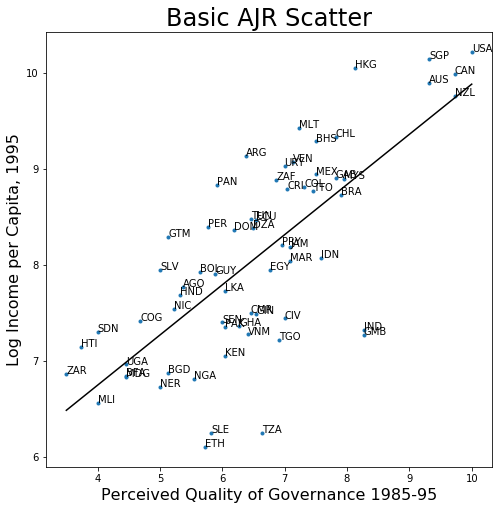

In [4]:
# 11.2.1. download the ajr data & look at the basic scatter:
#
# 'governancequality' is as perceived over 1985-1995 by the PRS Group <https://www.prsgroup.com>
# 'logincome' is the natural log of year-1995 real income per capita
#
# repeat from last time:

ajr_df = pd.read_csv('https://delong.typepad.com/files/ajr-2020.csv') # start by reading in the AJR data from the internet

ajr_df = ajr_df.dropna(subset=['logincome', 'governancequality']) # drop missing observations   # REMOVE BEFORE DEPLOYMENT
ajr_df = ajr_df[ajr_df['basesample'] == 1] # restrict our analysis to the AJR "base" sample   # REMOVE BEFORE DEPLOYMENT

# now remove missing observations (remember how to do this?)
# ajr_df = ...
# now restrict our analysis to the AJR "base" sample (remember how to do this?)
# ajr_df = ...

# now plot the scatter

fig, ax = plt.subplots(figsize=(8,8)) # tell python to expect figures to come
ax.scatter(ajr_df['governancequality'], ajr_df['logincome'], marker='.') # create the figure 

# now label the scatter-plot points
for i, txt in enumerate(ajr_df['shortid']): # loop through the data points
    ax.annotate(txt, (ajr_df['governancequality'].iloc[i], ajr_df['logincome'].iloc[i])) # labeling each data point

# now draw the best-fit relationship line
ax.plot(np.unique(ajr_df['governancequality']),
    np.poly1d(np.polyfit(ajr_df['governancequality'], 
    ajr_df['logincome'], 1))(np.unique(ajr_df['governancequality'])),
    color='black')

ax.set_xlabel('Perceived Quality of Governance 1985-95', size=16) # set the figure x-axis label # REMOVE BEFORE DEPLOYMENT
ax.set_ylabel('Log Income per Capita, 1995', size=16) # set the figure y-axis label # REMOVE BEFORE DEPLOYMENT
ax.set_title('Basic AJR Scatter', size=24) # set the figure title # REMOVE BEFORE DEPLOYMENT
plt.show() # show the figure # REMOVE BEFORE DEPLOYMENT

# ax.set... # set the figure x-axis label (remember how to do this?)
# ax.set... # set the figure y-axis label (remember how to do this?)
# ax.set... # set the figure title (remember how to do this?)
# plt...    # show the figure (remember how to do this?)


This data cloud is a cloud. The points do not lie, mechanically, on a straight line. There are some points—India, Tanzania, and Ethiopia, for example—are very far away from any positively-sloped underlying relationship line indeed. 

Hosever, there definitely is a relationship here: I count 29 points for which governance quality and log income are both less than average, 19 points for which both are greater than average, and only 12 points for which governance quality is less but prosperity greater than average and only 10 points for which governance quality is greater and prosperity less than average. And there is a least-squares best-fit most-likely relationship line. It has a slope $ \hat{\beta} = 0.5221 $

&nbsp;

## 3. Review: Understanding the Limits of the Bivariate Scatter: Uncertain Which Is Cause & Effect

We have an estimated relationship line between governance quality G and prosperity in the sense of income per capita Y. The equation for that line is:

>$ \log(Y) = 4.6604 + (5.221)G $

What does this line tell us? What does such an equation mean?

AJR are searching for a way to calculate how much good governance is the cause of prosperity. They have an estimated relationship line with a slope of $ \hat{\beta} = 0.5221 $. But is governance quality the cause, and prosperity the effect? Or is it prosperity—or the other factors that truly drive prosperity—that is the cause, and governance quality that is the effect? A prosperous country is, after all, one in which many institutions are working well—it is very plausible that whatever factors generated prosperity also generated good government. They cannot interpret the 0.522 as saying that if we had taken Haiti and somehow history had been different so that Haiti had (now and in the past) the governance quality of New Zealand, that Haiti would be likely to be 23 times richer now than it in fact as.

Last time we assumed that the level of prosperity Y is indeed determined by good governance G and by other, random, independent disturbance factors. We gather these together and add them up into the random variable which we call $ \epsilon $—a thing that varies, randomly, and thus that we cannot predict from inside the system. So we write the cause-and-effect equation for how good governance generates prosperity, with $ \beta $ being the strength of the true causal relationship running from governance quality to prosperity:

$ Y = \beta G + \epsilon $    

And we also assumed that prosperity Y causes high governance quality G by leading to a society in which people have the resources and the voice and the power to demand good governance:

$ G = \gamma( Y +  \nu ) $

Where here the other causes of governance quality G than prosperity Y are gathered into another random variable, $ \nu $.

In this two-equation system, it is the $ \epsilon $ and the $ \nu $ that are the drivers. They come into the system from outside, and they then generate Y and G. We can think of the $ \epsilon $  as shifting the prosperity-as-a-function-of-governance line up or down for that country, and of the $ \nu $ as shifting the governance-as-a-function-of-prosperity line up or down for that country, with each country's data point being that country's equilibrium point, where those two lines for that country intersect.

We want to specify the ratio of the variances of the shifter factors:

>$ \rho = \frac{\sigma^2_{\nu}} {\sigma^2_{\epsilon}} $

We can then solve for what Y and G as functions of the random variables $ \epsilon $ and $ \nu $:

>$ Y = \frac{1}{1 - \beta\gamma}\epsilon + \frac{\beta\gamma}{1 - \beta\gamma} \nu $    
>$ G = \frac{\gamma}{1 - \beta\gamma}\epsilon + \frac{\gamma}{1 - \beta\gamma} \nu  $

Applying our formal probability and statistics rules, we unpacked what is in Y and G to calculate:

>$  \hat{\beta} = \frac{\sigma_{YG}}{\sigma_{GG}} = 
 \left( \frac{ \rho}{1 + \rho} \right) \beta +  \left( \frac{1 }{1  + \rho} \right) \frac{1}{\gamma}
$

The slope $ \hat{\beta} $ of the best-fit relationship line is not expected to be the true causal relationship parameter $ \beta $, but rather a weighted average of:

1. the true $ \beta $ causal relationship between G and Y on the one hand, and 
2. the $ \frac{1}{\gamma} $ reverse-causation confounding term back from Y to G on the other, with
3. the weights in this weighted average depending on the ratio $ \rho $ of the disturbance variances.

When there are few shifts in the governance-as-a-function-of-prosperity line—when the variation of $ \nu $ is small relative to the variation in $ \epsilon $, and thus $ \rho $ is low—then the scatter has a slope very close to $ 1/\gamma $. The variation in $ \epsilon $ will shift different countries' prosperity-as-a-function-of-governance lines all over the place, and so the scatter will track and trace out the (almost constant across countries) governance-as-a-function-of-prosperity line.

When there are few shifts in the prosperity-as-a-function-of-governance—when the variation of $ \epsilon $ is small relative to the variation in $ \nu $, and thus $ \rho $ is high—then the scatter has a slope very close to $ \beta $. The variation in $ \nu $ will shift different countries' governance-as-a-function-of-prosperity lines all over the place, and so the scatter will track and trace out the (almost constant across countries) prosperity-as-a-function-of-governance line.

And we thus expect $ \hat{\beta} $ to be different from the true $ \beta $ according to:

$  \hat{\beta} - \beta =  
 \left( \frac{1 }{1  + \rho} \right) \left( \frac{1}{\gamma} - \beta \right)
$

&nbsp;

We need to have a strong and informed view about both the value of ɣ, the strength of the reverse-causation channel from prosperity back to high-quality governance, and of ⍴, the ratio of the variations, in order to judge what the $ \hat{\beta} = 0.522 $ tells us about β.

&nbsp;

## 4. Instrumental Variables Analysis

### A. The Benefits of an Instrument

AJR do not have strong and informed views about both the value of ɣ, the strength of the reverse-causation channel from prosperity back to high-quality governance, and of ⍴, the ratio of the variation. Hence AJR follow a different track.

Suppose that there was some other variable—let us call it C, for climate and its impact on settler mortality—that had an impact on quality of governance G, but aside from its impact on quality of governance had no other impact on or correlation with prosperity Y. Then our two equations would be :

>$ Y = \beta G + \epsilon $

>$ G = \delta C + \gamma( Y +  \nu ) $

Now let's get the Y and the Gs out of the right-hand sides:

>$ G = \left( \frac{\delta}{1 - \beta\gamma } \right)C + \left( \frac{\gamma}{1 - \beta\gamma } \right)( \epsilon +  \nu ) $

>$ Y = \beta\left(\frac{ \delta}{1 - \beta \gamma}\right) C + 
    \left(\frac{\beta \gamma}{1 - \beta \gamma}\right) \nu  + \left(\frac{1}{1 - \beta \gamma}\right)\epsilon $

Now suppose we calculated what we would have expected G to be if all we had known about was C:

>$ \hat{G} = \left(\frac{ \delta}{1 - \beta \gamma}\right) C $

And then calculated:

>$ \hat{\beta}_{IV} = \frac{\sigma_{\hat{G}Y}}{\sigma^2_{\hat{G}}} $

what would we get? 

Well, remember from our rules for doing this probability-statistical algebra:

>$ \sigma_{\hat{G}}^2 = \left( \frac{\delta}{1 - \gamma \beta} \right)^2 \sigma_C^2 $

>$ \sigma_{Y\hat{G}} = \beta \left( \frac{\delta}{1 - \gamma \beta} \right)^2 \sigma_C^2 $

>$ \hat{\beta}_{IV} = \beta $

We would find the true causal relationship from prosperity to income, uncorrupted by reverse causation. And all our problems would be gone—save for the problem of finding such an instrumental variable C.

&nbsp;

### B. European-Settler Mortality

Acemoglu, Johnson, and Robinson believe that they have found such a variable in the weather, or rather the climate—specifically, early European-settler mortality. They take the risk that European settlers early in the colonial era would die if they took up residence in a colony to be a _valid instrumental variable_: something that is correlated with their x-axis cause variable, governance quality, and _correlated with the y-axis effect variable, prosperity, only to the extent that governance quality causes prosperity_. 

AJR argue that settler "mortality rates were a key determinant of European settlement." Where the climate was favorable and thus settler mortality was low, Europeans settled in large numbers and established "settler colonies". And these then gave rise to pro-prosperity "developmental institutions" with high-quality governance:

>Where Europeans settled in large numbers, and life was modeled after the home country.... The settlers wanted... freedom and the ability to get rich by engaging in trade.... When the establishmentof European-like institutions did not arise naturally, the settlers were ready to fight for them against the wishes of the home country.... The settlers wanted institutions and political rights like those prevailing in England at the time. They demanded jury trials, freedom from arbitrary arrest, and electoral representation...

By contrast, where the climate was unfavorable, European colonialist powers imposed "extractive institutions":

>There were few constraints on state power in the nonsettler colonies. The colonial powers set up authoritarian and absolutist states with the purpose of solidifying their control and facilitating the extraction of resources...

These then gave rise to anti-prosperity low-quality governance:

>The control structure set up in the nonsettler colonies during the colonial era persisted.... The institutions of law and order and private property established during the early phases of colonialism in Australia, Canada, New Zealand, the United States, Hong Kong, and Singapore have formed the basis of the current-day institutions of these countries.... [And] the extractive institutions set up by the colonialists persisted long after the colonial regime ended...

Extractive institutions then make it much more likely that quality-of-governance is low now. Low-quality governance contributes to present-day poverty. And, AJR argue, there are no other alternative causal links between a favorable or unfavorable climate for settlement then to prosperity or poverty now. The only way that climate then and prosperity now are linked is through this chain of causation: from climate to institutions then, from institutions then to governance quality now, and from governance quality now to prosperity now.

&nbsp;

### C. AJR Claim to Estimate the Causal Relationship

Let us, for the moment, provisionally pursue AJR's line of reasoning. Suppose that these claims are true. Then we can figure out $ \hat{G} $—what we would have expected governance-quality to be from the country's settler-mortality climate—by asking the Python interpreter to calculate what the relationship line between C and G:

In [5]:
# 11.4.C.1. relationship between governancequality and settler mortality

ajr_df['constant'] = 1

print(sm.OLS(endog=ajr_df['governancequality'], 
                exog=ajr_df[['constant', 'logsettlermortality']], 
                missing='drop').fit().summary())

                            OLS Regression Results                            
Dep. Variable:      governancequality   R-squared:                       0.270
Model:                            OLS   Adj. R-squared:                  0.258
Method:                 Least Squares   F-statistic:                     22.95
Date:                Thu, 26 Nov 2020   Prob (F-statistic):           1.08e-05
Time:                        08:30:56   Log-Likelihood:                -104.83
No. Observations:                  64   AIC:                             213.7
Df Residuals:                      62   BIC:                             218.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
constant                9.3414    

And then in the next code cell, use those two coefficients 9.3414 and -0.6068 to calculate what we would have expected governance quality to be if all we knew was what settler mortality had been:

In [6]:
# 11.4.C.2. calculating what governance quality we would expect given settler mortality

ajr_df['governance_quality_iv'] = 9.3414 - 0.6068 * ajr_df['logsettlermortality'] # DELETE BEFORE DEPLOYING

# ajr_df['governance_quality_iv'] = ...

Then we can draw the scatter diagram and the relationship line—only putting not governance quality but the portion of governance quality that is related to settler mortality on the x-axis. And then the slope of this relationship line is supposed, according to AJR, to give us the strength of the causal relationship running from governance quality to prosperity: 

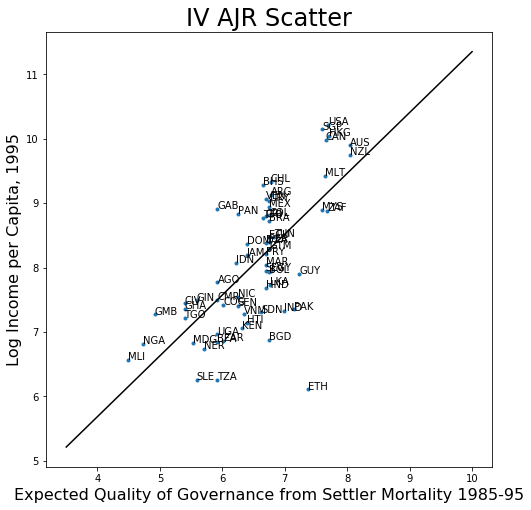

In [7]:
# 11.4.C.3. draw the chart, and also draw a straight
# least-squares fit line through the data

fig, ax = plt.subplots(figsize=(8,8)) 

# create the figure with average expropriation risk on the horizontal and
# 1995 per capita real income on the vertical axis

ax.scatter(ajr_df['governance_quality_iv'], ajr_df['logincome'], marker='.')  # DELETE BEFORE DEPLOYING

# ax.scatter(...

# now loop through the data points in the figure, annotating each
# data point with a three letter code ('Threeletterabbrevation') identifying the 
# country refered to:

for i, txt in enumerate(ajr_df['shortid']):
    ax.annotate(txt, (ajr_df['governance_quality_iv'].iloc[i], ajr_df['logincome'].iloc[i]))
    
ax.plot(np.unique(ajr_df['governancequality']),
    np.poly1d(np.polyfit(ajr_df['governance_quality_iv'], ajr_df['logincome'], 1))(np.unique(ajr_df['governancequality'])),
    color='black')

# set the figure labels, and show the figure:

ax.set_xlabel('Expected Quality of Governance from Settler Mortality 1985-95', size=16) # DELETE BEFORE DEPLOYING
ax.set_ylabel('Log Income per Capita, 1995', size=16) # DELETE BEFORE DEPLOYING
ax.set_title('IV AJR Scatter', size=24) # DELETE BEFORE DEPLOYING
plt.show()

# ax.set... # set the x-axis label
# ax.set... # set the y-axis label
# ax.set... # set the title label
# plt...    # show the scatter

&nbsp;

### D. Assessing This Instrumental-Variable AJR Estimate

We gain a lot of insight by plotting this side-by-side our original scatter:

<img src="https://delong.typepad.com/img/ajr-ols-%26-iv.png" width="800" />

We were expecting to find out from this analysis how far the true $ \beta $ was below the originally estimated $ \hat{\beta} $: we were expecting to find a flatter line than in our original scatter, because we have purged it of the reverse causation back from prosperity to good governance. Instead, we have found—if we trust this instrumental-variables procedure—that we have a $ \hat{\beta}_{IV} = 0.9443 $, not smaller but larger than our $ \hat{\beta}_{OLS} = 0.5221 $.

What are we to make of this?

Arithmetically, it is clear what is going on. A lot of the very good institutions of rich countries are features that we would not have expected to see given that back early in the age of imperialism their settler mortality climate was not _that_ low, and a lot of the very bad institutions of poor countries are features that we would not have expected to see given that back early in the age of imperialism their settler mortality climate was not _that_ high. Thus the $ \sigma_\hat{G}^2 $ is low. And so, when we divide the correlation $ \sigma_{Y\hat{G}} $ between expected institutions and prosperity by the small $ \sigma_\hat{G}^2 $, we get a large number.

Remember that we thought our original $ \hat{\beta} $ was not trustworthy as an estimate of the true causal slope $ \beta $ because there was this $ \gamma $ reverse causation from prosperity back to governance quality in the mix. What does this instrumental-variables result tell us about the strength of this $ \gamma $ reverse causation?

Remember the relationship between the best-fit line slope from the scatter $ \hat{\beta} $ and the true $ \beta $ that tells us the strength of the causal relationship—how much raising governance-quality G by one unit raises prosperity Y:

$  \hat{\beta} - \beta =  
 \left( \frac{1 }{1  + \rho} \right) \left( \frac{1}{\gamma} - \beta \right)
$

We have our orgoinal scatter $  \hat{\beta}_{OLS} = 0.5221 $ and, if the instrumental-variables estimate is correct, $ \beta =  0.9443 $. That would then mean, if the instrumental-variables analysis is correct, that:

$  0.5221 - 0.9443 =  
 \left( \frac{1 }{1  + \rho} \right) \left( \frac{1}{\gamma} - 0.9443 \right)
$

$ -0.4222 - 0.4222\rho = - 0.9443 + \frac{1}{\gamma} $

$ 0.5221 - 0.4222\rho =  \frac{1}{\gamma} $

In the next code cell, program up and plot this relationship between the variance-of-disturbances ratio $ \rho $ and the effect of prosperity on governance quality $ \gamma $ for $ \rho $ varying between 0.01 and 1.23. Do so by constructing two lists, rho_series and gamma_series, that will then be plotted, with the gamma_series containing the value you calculate for $ \gamma $ for each corresponding value of $ \rho $ 

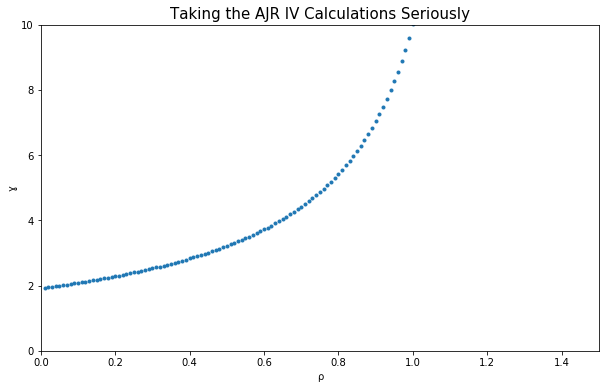

In [8]:
# 11.4.D.1. relationship between variance ratio 𝜌 and causal effect of prosperity on governance quality 𝛾

beta_hat = 0.5221
beta = 0.9443
rho_series = []
gamma_series = []

for i in range(1,123):                       # REMOVE BEFORE DEPLOYMENT
    rho = i/100                               # REMOVE BEFORE DEPLOYMENT
    gamma = 1/(0.5221 - 0.4222*rho)          # REMOVE BEFORE DEPLOYMENT
    gamma_series = gamma_series + [gamma]    # REMOVE BEFORE DEPLOYMENT
    rho_series = rho_series + [rho]          # REMOVE BEFORE DEPLOYMENT
    
# ...
# ...
# ...
# ...
# ...

fig, ax = plt.subplots(figsize=(10,6)) 

# create the figure with average expropriation risk on the horizontal and
# 1995 per capita real income on the vertical axis

ax.scatter(rho_series, gamma_series, marker='.')

ax.set_xlabel('⍴', size=10)
ax.set_ylabel('ɣ', size=10)
ax.set_ylim(0, 10)
ax.set_xlim(0, 1.5)
ax.set_title('Taking the AJR IV Calculations Seriously', size=15)
plt.show()

For a variance ratio $ \rho < 1.2366 $, in order to get a best-fit line with a slope $ \hat{\beta} = 0.5223 $ in the full scatter while the true causal effect $ \beta $ of better governance on higher prosperity is $ \beta = 0.9441 $, there must be a very strong and very positive causal effect of governance-quality on prosperity: a high value of $ \gamma $.

This is a problem: A high value of $ \gamma $ means that relatively small differences in prosperity across countries set in motion social forces that lead to very large increases in quality of governance. It is plausible to point at history and political economy and argue that higher governance quality leads to more prosperity. But few (if any) historians and analysts point at history and political economy and argue that there are very strong forces leading from prosperity to higher governance quality. Some, yes—that prosperity has some impact, and that factors making for general societal competence have an impact on both. But a very strong cause-and-effect relationship? Implausible.

Things are even worse for a variance ratio greater than $ \rho > 1.2366 $. In the next code cell, program up and plot this relationship between the variance-of-disturbances ratio $ \rho $ and the effect of prosperity on governance quality $ \gamma $ for $ \rho $ varying between 1.3 and 10. Do so by constructing two lists, rho_series and gamma_series, that will then be plotted, with the gamma_series containing the value you calculate for $ \gamma $ for each corresponding value of $ \rho $ 

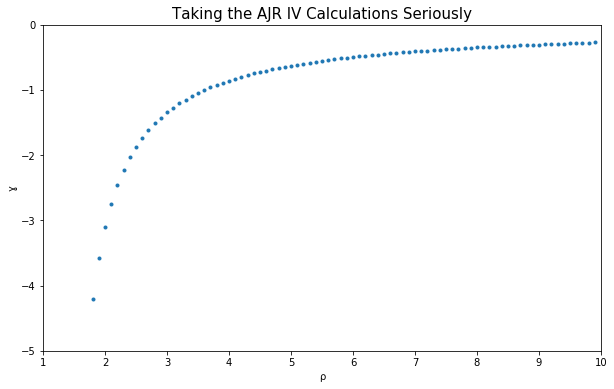

In [9]:
# 11.4.D.2. relationship between variance ratio 𝜌 and causal effect of prosperity on governance quality 𝛾

beta_hat = 0.5221
beta = 0.9443
rho_series = []
gamma_series = []

for i in range(13,100):                      # REMOVE BEFORE DEPLOYMENT
    rho = i/10                               # REMOVE BEFORE DEPLOYMENT
    gamma = 1/(0.5221 - 0.4222*rho)          # REMOVE BEFORE DEPLOYMENT
    gamma_series = gamma_series + [gamma]    # REMOVE BEFORE DEPLOYMENT
    rho_series = rho_series + [rho]          # REMOVE BEFORE DEPLOYMENT
    
# ...
# ...
# ...
# ...
# ...

fig, ax = plt.subplots(figsize=(10,6)) 

# create the figure with average expropriation risk on the horizontal and
# 1995 per capita real income on the vertical axis

ax.scatter(rho_series, gamma_series, marker='.')

ax.set_xlabel('⍴', size=10)
ax.set_ylabel('ɣ', size=10)
ax.set_ylim(-5, 0)
ax.set_xlim(1, 10)
ax.set_title('Taking the AJR IV Calculations Seriously', size=15)
plt.show()

For a variance ratio greater than $ \rho > 1.2366 $, to reconcile our original scatter with its slope and the instrumental-variables analysis with its slope, we need there to be a _negative_ causal relationship between prosperity and governance-quality. A country's being richer needs to cause—or other factors that lead to a country's being richer need also to cause—the quality of governance to decline: more corruption, more inefficiency, and a greater fear of expropriation.

Now this makes no sense at all. Historically, revolutions and expropriations have not occurred in rich but in poor countries. And it seems to be trying swallow a camel to say that the other things that cause prosperity also cause low-quality government.

&nbsp;

## 5. How Do AJR Reconcile Their Findings?

### A. Defense of the Validity of Their Instrument

AJR are thus confronted with a puzzle. Hence they drop their arguments that:

>It is plausible that rich economies are able to afford, or perhaps prefer, better institutions. Arguably more important than this reverse causality problem, there are many omitted determinants of income differences that will naturally be correlated with institutions. Finally, the measures of institutions are constructed ex post, and the analysts may have had a natural bias in seeing better institutions in richer places...

And they focus on:

>The fact that the institutions variable is measured with considerable error creates attenuation and may bias the OLS estimates downwards.... [Andf in fact this] measurement error in the institutions variables that creates attenuation bias is likely to be more important...

But they make no mention of the either very strong positive or negative causal relationship running from prosperity to governance-quality that taking their settler-mortality C variable to be a valid instrument implies.

Instead, they turn to arguing that their instrumental-variable results are trustworthy, and as a result there are:

>large effects of institutions on income per capita... [that] account for roughly three-quarters of the differences in income per capita...

If we considered an alternative counterfactual world in which other, outside factors had reached in and enforced institutions of equal quality in all countries of the globe, and let that equal institutional quality together with the other factors that determine institutions in our world operate, we would find three-quarters of our world's variation in prosperity gone.

They are confident in this conclusion.

Why are they confident? Because, they argue, their settler-mortality C variable is a valid instrument:

>Settler mortality affected settlements; settlements affected early institutions; and early institutions persisted.... The validity of our... results... depends on the assumption that settler mortality in the past has no direct effect on current economic performance. Although this presumption appears reasonable, here we substantiate it further by directly controlling for many of the variables that could plausibly be correlated with both settler mortality and economic outcomes. Overall, we find that our results change remarkably little with the inclusion of these variables, and many variables emphasized in previous work become insignificant once the effect of institutions is controlled for.... identity of
the colonial power... legal origin... the fraction of the populations that are Catholic, Muslim, and of other religions... temperature and humidity... average, minimum and maximum monthly high temperatures, and minimum and maximum monthly low temperatures, and morning minimum and maximum humidity, and afternoon minimum and maximum humidity... the prevalence of malaria... the current population... fraction of Europeans... ethnolinguistic fragmentation... soil quality and natural resources... whether the country is landlocked.... The effect of variations in institutions caused by early colonial experience on income is robust, and likely captures the causal effect of institutions and government policies on economic well-being...

They propose an alternative theory—that their instrumental-variables estimate is higher because the best-fit line through the original scatter is reduced in slope by "attenuation bias". Once more dropping into math, suppose that, as before, governance-quality leads to prosperity through a causal channel the strength of which is measured by the value of $ \beta $:

>$ Y = \beta G + \epsilon $  

But we do not see $ G $. Instead, we see a corrupted and flawed measure of "true" governance quality $ H $:

>$ H = G = \eta $.

If this is true, then our original slope from the original full scatter is thus:

>$ \hat{\beta}_{OLS} = \frac{\sigma_{YH}}{\sigma_H^2} $

By our rules of statistical algebra:

>$ \sigma_{YH} = \beta \sigma_G^2 $

>$ {\sigma_H^2} = \sigma_G^2 + {\sigma_{\eta}^2} $

Hence:

>$ \hat{\beta}_{OLS} = \beta \left( \frac{\sigma_G^2}{\sigma_G^2 + \sigma_{\eta}^2} \right) $

The scatter slope is reduced below the true causal slope by the attenuation factor $  \left( \frac{\sigma_G^2}{\sigma_G^2 + \sigma_{\eta}^2} \right) $

In order for this explanation to work, however, settler mortality early in the age of imperialism has to (a) be correlated with that part of modern-day institutions that matter for prosperity, the G, while also (b) being uncorrelated with those parts of modern-day institutions that do not matter for prosperity, the $ \eta $. The original best-fit scatter line attributes the superior prosperity of the countries in the upper-right of the scatter—the USA, Canada, Australia, New Zealand, Singapore and company—to their possession of institutions of higher quality by 3.5 points on the PRS scale. But given settler mortality, we would only have anticipated that they would have institutions of 2 points higher quality on the PRS scale—and it is those 2 points that matter, with the extra 1.5 points being spurious features of today's institutions that we regard as good government, but that are not in fact important.

&nbsp;

### B. My Assessment

Thus we can resolve this puzzle in one (or perhaps more) of four different ways:

1. There is reverse causation from prosperity to governance quality, but it runs in the counterintuitive direction—more prosperity sets in motion social processes that reduce the quality of governance.
2. There is reverse causation from prosperity to governance quality, and it is very strong—small positive differences in prosperity for countries with the same $ \nu $ factors lead to very large positive differences in governance quality.
3. Settler mortality early age of imperalism is much more highly correlated with those features of today's institutions that matter for prosperity than with those features of today's institutions that do not matter for prosperity.
4. Independent of the causal association between settler morality and institutions in the past, between institutions in the past and institutions today, and between institutions today and prosperity, the factors that made regions unhealthy for European settlers early in the age of imperialism either make or are correlated with factors that make countries poor today.

We do not know for certain. But if I had to bet, I would bet on (4).


## 6. Done!

Print your finished notebook to pdf, and upload it as an answer on the problem set 11 assignment page. URL: 

## 7. Appendix: Programming Dos and Don'ts...

### A Running List...

1. **Do** restart your kernel and run cells up to your current working point every fifteen minutes or so. Yes, it takes a little time. But if you don't, sooner or later the machine's namespace will get confused, and then you will get confused about the state of the machine's namespace, and by assuming things about it that are false you will lose hours and hours...   
&nbsp;

2. **Do** reload the page when restarting the kernel does not seem to do the job...   
&nbsp;

3. **Do** edit code cells by copying them below your current version and then working on the copy: when you break everything in the current cell (as you will), you can then go back to the old cell and start fresh...   
&nbsp;

4. **Do** exercise agile development practices: if there is a line of code that you have not tested, test it. The best way to test is to ask the machine to echo back to you the thing you have just created in its namespace to make sure that it is what you want it to be. Only after you are **certain** that your namespace contains what you think it does should you write the next line of code. And then you should immediately test it...   
&nbsp;

5. **Do** take screenshots of your error messages...   
&nbsp;

6. **Do** google your error messages: Ms. Google is your best friend here...   
&nbsp;

7. **Do not** confuse assignment ("=") and test for equality ("=="). In general, if there is an "if" anywhere nearby, you should be testing for equality. If there is not, you should be assignment a variable in your namespace to a value. **Do** curse the mathematicians 500 years ago who did not realize that in the twenty-first century it would be very convenient if we had different and not confusable symbols for equals-as-assignment and equals-as-test...   
&nbsp;

----

&nbsp;

**Thanks to**: Rachel Grossberg, Christopher Hench, Meghana Krishnakumer, Seth Lloyd, Ronald Walker...

----

&nbsp;

## <font color="880000"> Governance & Prosperity III </font>

<img src="https://tinyurl.com/20190119a-delong" width="300" style="float:right" />

### <font color="000088">Catch Our Breath—Further Notes:</font>

<https://github.com/braddelong/econ-115-f-2020-assignments/blob/master/ps11.ipynb>   
<http://datahub.berkeley.edu/user-redirect/interact?account=braddelong&repo=econ-115-f-2020-assignments&branch=master&path=ps11.ipynb>

<br clear="all" />

----



&nbsp;

----